In [1]:
import shap
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

/home/liperasz/miniconda3/envs/card-26/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# carregando o dataset
data = load_breast_cancer()

In [3]:
# pegando os valores de X e Y
X, y = data['data'], data['target']

In [4]:
# nome dos rótulos
data['target_names']

array(['malignant', 'benign'], dtype='<U9')

In [5]:
# separando os dados de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [6]:
# criando o classificador
clf = LinearSVC()
# treinando
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [7]:
# vendo a accuracy no teste
clf.score(X_test, y_test)

0.9385964912280702

In [8]:
# fazendo uma predição
clf.predict([X_test[0]])

array([0])

In [9]:
# explicador do modelo, com 10 pontos representativos do treino
explainer = shap.KernelExplainer(clf.predict, shap.kmeans(X_train, 10))

In [ ]:
# calcula os valores do SHAP, que indica para cada variavel a influencia dela na decisao
shap_values = explainer.shap_values(X_test)

100%|██████████| 114/114 [00:05<00:00, 22.14it/s]


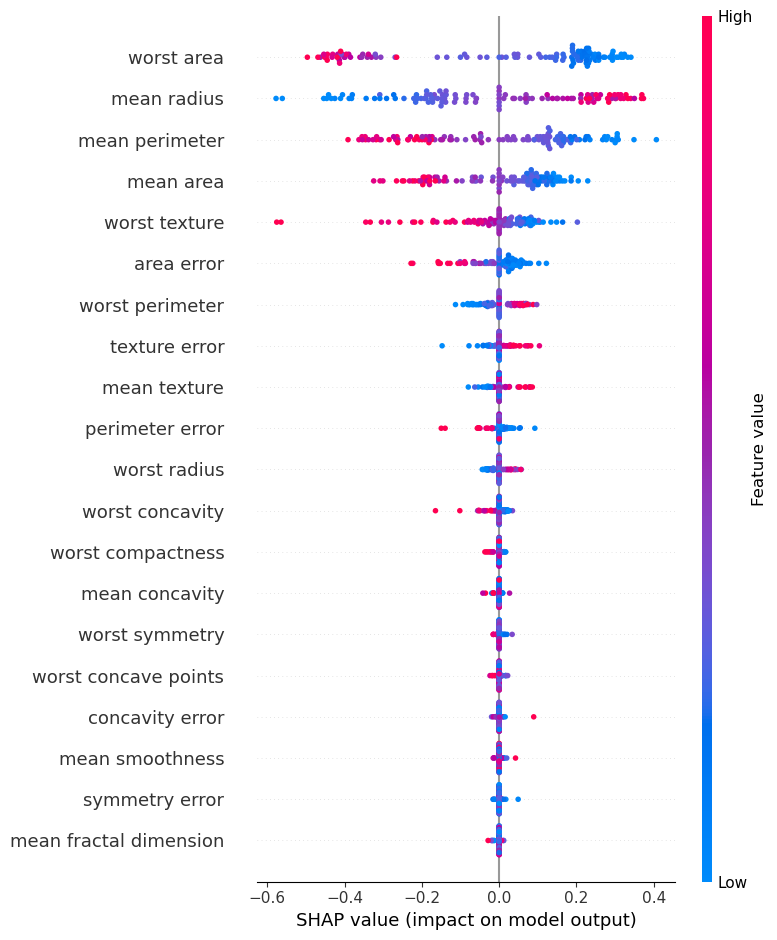

In [11]:
# gráfico com a importancia de cada caracteristica
shap.summary_plot(shap_values, X_test, feature_names=data['feature_names'])

In [ ]:
# carrega o javascript para exibir o grafico
shap.initjs()
# exibe um grafico focado em uma predição especifica
shap.force_plot(explainer.expected_value, shap_values[0], X_test[0], feature_names=data['feature_names'])

In [ ]:
# calcula a media geral da importancia de cada variavel
mean_abs_shap_values = np.abs(shap_values).mean(axis=0)

In [ ]:
# criando dicionario com nome das variaveis e importancia media
feature_names = data['feature_names']
feature_importance = zip(feature_names, mean_abs_shap_values)

In [ ]:
# ordenando
sorted_feature_importance = sorted(feature_importance, key=lambda x: x[1], reverse=True)

In [16]:
# mostrando a importancia de cada variavel
for feature, importance in sorted_feature_importance:
    print(feature, '-->', importance)

worst area --> 0.2539925978587318
mean radius --> 0.2100462373506893
mean perimeter --> 0.18217638485084597
mean area --> 0.11617699941752395
worst texture --> 0.07774491334211565
area error --> 0.04490720413258306
worst perimeter --> 0.03547671342949713
texture error --> 0.014622797271990206
mean texture --> 0.013215953844297423
perimeter error --> 0.013180720622001391
worst radius --> 0.013156459445150348
worst concavity --> 0.011135668234603416
worst compactness --> 0.0029581547957336523
mean concavity --> 0.0018393956669865326
worst symmetry --> 0.0016742149180648622
worst concave points --> 0.001640702927005452
concavity error --> 0.0016352178933872865
mean smoothness --> 0.0016258054228687879
symmetry error --> 0.00146337795690676
mean fractal dimension --> 0.0012900822069786418
concave points error --> 0.001005037997421146
mean compactness --> 0.0009666432480293083
compactness error --> 0.0009440507743861715
worst smoothness --> 0.0009401374574962015
smoothness error --> 0.00077